# Исследование характеристик СМО с помощью имитационного моделирования

## Цели работы:
1. Запустить эксперимент для СМО M/M/1 и сравнить с аналитикой.
2. Провести эксперимент для СМО M/U/1 и сравнить с формулой Поллачека-Хинчина.
3. Модифицировать симулятор для реализации M/M/c/c (система с отказами) и проанализировать вероятность блокировки и среднее время в системе в зависимости от количества каналов $c$.

## Что было сделано

1. Посмотрел код симулятора
2. Исправил в нем названия переменных, чтобы они соответствовали тому, что означают (например, очередь на самом деле не очередь, а вся система)
3. Добавил возможность выбора режима работы под свое задание (см. ниже)
4. Реализовал M|U|1 и M|M|c|c (см. diff)
5. Построил графики и сравнил с аналитикой (см. ниже)

## Импорты и базовые функции

In [1]:
import subprocess
import numpy as np
import math
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm
import os
from concurrent.futures import ThreadPoolExecutor
import scipy.stats as stats
import sys

sys.path.append(r"D:\git\MIPT\tools")

import plot_tools

# make clean && make

### Запускает один прогон и выдает требуемые метрики

Было реализовано три режима в соответствии с тремя целями

In [9]:
def run_simulation(seed, lambd, mu, sim_time, mode, c=1):
    """
    mode: 0 - M/M/1, 1 - M/U/1, 2 - M/M/c/c
    """
    
    process_id = os.getpid()
    
    executable = os.path.join("src", "scenario.exe")
    
    cmd = f"{executable} {seed} {lambd} {mu} {sim_time} {mode} {c}"
    result = subprocess.run(cmd.split(), capture_output=True, text=True)
    
    # Served, SojournTime, WaitTime, AvgSize, Util, DropProb
    metrics = list(map(float, result.stdout.split()))
    
    return metrics[1], metrics[5] # Sojourn Time и Drop Probability


In [10]:
def get_confidence_interval(data, alpha=0.01):
    if len(data) < 2: return 0.0
    return (np.sqrt(np.var(data, ddof=1) / len(data)) * 
            stats.t.ppf(1 - alpha/2, len(data) - 1))

### Реализовал параллельное исполнение не через parralel, а ThreadPoolExecutor

In [11]:
def run_experiment(lambd, mu=1.0, sim_time=100000, mode=0, c=1, target_beta=0.1, batch_size=None, seed_counter_max=1000):
    
    # Если batch_size не указан, берем количество логических ядер процессора
    if batch_size is None:
        batch_size = os.cpu_count() or 4
    
    sojourn_times = []
    drop_probs = []
    seed_counter = 1

    # Убрал разделение режимов на динамический/статический, оставил смешанный. Вполне можно выставить batch_size = 1 и очень маленькую beta => будет статический режим
    # Если beta нормальная и batch_size порядка числа процессоров, то будет аналог динамического режима с параллельным исполнением по пачкам до остановки
    with ThreadPoolExecutor(max_workers=batch_size) as executor:
        while True:
            seeds = list(range(seed_counter, seed_counter + batch_size))
            seed_counter += batch_size
            
            results = list(executor.map(lambda s: run_simulation(s, lambd, mu, sim_time, mode, c), seeds))
            sojourn_times.extend([r[0] for r in results])
            drop_probs.extend([r[1] for r in results])
            
            if len(sojourn_times) >= 2:
                conf_interval = get_confidence_interval(sojourn_times)
                # Достигнута необходимая точность или превышен лимит прогонов
                if conf_interval <= target_beta or seed_counter > seed_counter_max:
                    # if seed_counter > seed_counter_max:
                        # print("Превышен лимит прогонов")
                    break
                
                    
    return np.mean(sojourn_times), get_confidence_interval(sojourn_times), np.mean(drop_probs), get_confidence_interval(drop_probs)

# M|M|1

Это простейшая одноканальная система с пуассоновским входящим потоком и экспоненциальным временем обслуживания. Среднее время пребывания заявки в системе (Sojourn Time), включающее время ожидания в очереди и время обслуживания, определяется формулой:

$$W = \frac{1}{\mu - \lambda}$$

Условие стационарности: $\r < 1$. При приближении $\lambda$ к $\mu$ время нахождения в системе стремится к бесконечности.


In [12]:
r_1_mm1 = 0.1
r_2_mm1 = 0.95

mu = 1.0
lambdas_mm1 = np.linspace(r_1_mm1 * mu, r_2_mm1 * mu, 45)
sim_time = 100_000

sojourn_mean_mm1 = []
sojourn_ci_mm1 = []

for lambd in tqdm(lambdas_mm1):
    st_mean, st_ci, _, _ = run_experiment(lambd, mu, sim_time, mode=0, seed_counter_max=20, target_beta=0.1)
    sojourn_mean_mm1.append(st_mean)
    sojourn_ci_mm1.append(st_ci)

  0%|          | 0/45 [00:00<?, ?it/s]

In [6]:
# Аналитика M/M/1
lambdas_analyt = np.linspace(r_1_mm1 * mu, r_2_mm1 * mu, 100)
analytics_mm1 = 1.0 / (mu - lambdas_analyt)

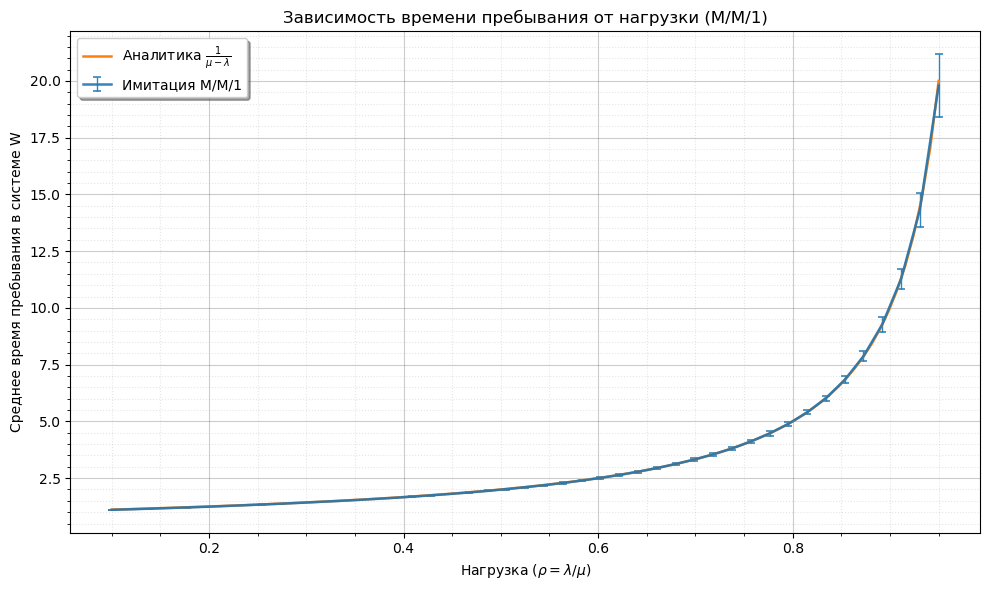

In [7]:
plot_tools.plot_signals(
    y=[np.array(sojourn_mean_mm1), analytics_mm1],
    x=[lambdas_mm1, lambdas_analyt],
    labels=['Имитация M/M/1', r'Аналитика $\frac{1}{\mu-\lambda}$'],
    errors=[(np.array(sojourn_ci_mm1), None), (None, None)],
    show_err=True,
    title='Зависимость времени пребывания от нагрузки (M/M/1)',
    xlabel=r'Нагрузка ($\rho = \lambda/\mu$)',
    ylabel='Среднее время пребывания в системе W',
    save_name="mm1.pdf"
)

## M|U|1

Для систем с произвольным распределением времени обслуживания (M/G/1) используется формула Поллачека-Хинчина. Среднее время пребывания $W$ выражается через моменты времени обслуживания $S$:

$$W = E[S] + \frac{\lambda E[S^2]}{2(1 - \rho)}$$

В нашем случае время обслуживания распределено равномерно $U(0, \frac{2}{\mu})$. Рассчитаем его характеристики:
*   Математическое ожидание: $E[S] = \frac{0 + \frac{2}{\mu}}{2} = \frac{1}{\mu}$
*   Дисперсия: $Var[S] = \frac{(\frac{2}{\mu} - 0)^2}{12} = \frac{4}{12\mu^2} = \frac{1}{3\mu^2}$
*   Второй начальный момент: $E[S^2] = Var[S] + (E[S])^2 = \frac{1}{3\mu^2} + \frac{1}{\mu^2} = \frac{4}{3\mu^2}$

Подставляя эти значения в формулу П-Х, получаем:

$$W_{M/U/1} = \frac{1}{\mu} + \frac{\lambda \frac{4}{3\mu^2}}{2(1 - \rho)} = \frac{1}{\mu} \left( 1 + \frac{2\rho}{3(1 - \rho)} \right)$$

Заметим, что из-за меньшей дисперсии (у экспоненциального распределения она $\frac{1}{\mu^2}$), время пребывания в M/U/1 будет меньше, чем в M/M/1 при той же нагрузке.


In [8]:
r_1_mu1 = 0.1
r_2_mu1 = 0.95

mu = 1.0
lambdas_mu1 = np.linspace(r_1_mu1 * mu, r_2_mu1 * mu, 45)
sim_time = 100_000

sojourn_mean_mu1 = []
sojourn_ci_mu1 = []

for lambd in tqdm(lambdas_mu1):
    st_mean, st_ci, _, _ = run_experiment(lambd, mu, sim_time, mode=1, seed_counter_max=20, target_beta=0.1)
    sojourn_mean_mu1.append(st_mean)
    sojourn_ci_mu1.append(st_ci)

  0%|          | 0/45 [00:00<?, ?it/s]

In [9]:
# Аналитика M/U/1
lambdas_analyt = np.linspace(r_1_mu1 * mu, r_2_mu1 * mu, 100)
analytics_mu1 = (1.0 / mu) + (lambdas_analyt * (4.0 / (3.0 * mu**2))) / (2.0 * (1.0 - (lambdas_analyt/mu)))

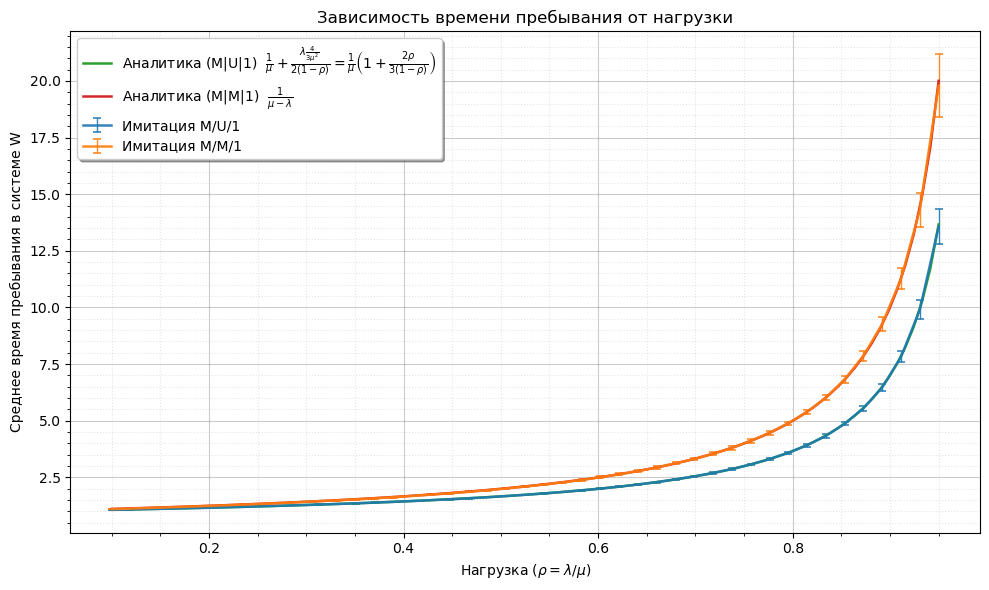

In [ ]:
plot_tools.plot_signals(
    y=[np.array(sojourn_mean_mu1), np.array(sojourn_mean_mm1), analytics_mu1, analytics_mm1],
    x=[lambdas_mu1, lambdas_mm1, lambdas_analyt, lambdas_analyt],
    labels=['Имитация M/U/1', 'Имитация M/M/1',r'Аналитика (M|U|1) $\ \frac{1}{\mu} + \frac{\lambda \frac{4}{3\mu^2}}{2(1 - \rho)} = \frac{1}{\mu} \left( 1 + \frac{2\rho}{3(1 - \rho)} \right)$', r'Аналитика (M|M|1) $\ \frac{1}{\mu-\lambda}$'],
    errors=[(np.array(sojourn_ci_mu1), None), (np.array(sojourn_ci_mm1), None), (None, None), (None, None)],
    show_err=True,
    title='Зависимость времени пребывания от нагрузки',
    xlabel=r'Нагрузка ($\rho = \lambda/\mu$)',
    ylabel='Среднее время пребывания в системе W',
    save_name="mu1.pdf"
)

## M|M|c|c

Это многоканальная система с отказами. В ней нет очереди: если все $c$ каналов заняты, новая заявка отбрасывается (теряется).

**Вероятность отказа (блокировки)** определяется первой формулой Эрланга (Erlang B):

$$P_B = \frac{\frac{r^c}{c!}}{\sum_{k=0}^{c} \frac{r^k}{k!}}$$

**Среднее время пребывания** в такой системе для *принятых* заявок не зависит от нагрузки и количества каналов, так как заявка сразу попадает на обслуживание и не стоит в очереди:

$$W = E[S] = \frac{1}{\mu}$$

In [11]:
def erlang_b(r, c):
    num = (r ** c) / math.factorial(c)
    den = sum((r ** i) / math.factorial(i) for i in range(c + 1))
    return num / den

In [12]:
mu = 1.0
r_min_mmcc = 0.01
r_max_mmcc = 10.0
c_values = [1, 2, 5]

sim_time=1_000

lambdas_mmcc = np.linspace(r_min_mmcc * mu, r_max_mmcc * mu, 45)


In [13]:
y_data_to_plot = []
labels_to_plot = []
errors_to_plot = []
styles_to_plot = []

for c in tqdm(c_values):
    sim_drop_means = []
    sim_drop_cis = []
    
    for lambd in lambdas_mmcc:
        # mode=2 для M/M/c/c
        _, _, d_mean, d_ci = run_experiment(lambd, mu, sim_time=sim_time, mode=2, c=c, target_beta=0.01, seed_counter_max=20)
        sim_drop_means.append(d_mean)
        sim_drop_cis.append(d_ci)
    
    # Симуляция
    y_data_to_plot.append(np.array(sim_drop_means))
    errors_to_plot.append((np.array(sim_drop_cis), None))
    labels_to_plot.append(f'Имитация c={c}')
    styles_to_plot.append('')
    
    # Аналитика (Erlang B)
    analyt_drop_vals = np.array([erlang_b(l/mu, c) for l in lambdas_mmcc])
    y_data_to_plot.append(analyt_drop_vals)
    errors_to_plot.append((None, None))
    labels_to_plot.append(f'Аналитика Erlang B (c={c})')
    styles_to_plot.append('--')

  0%|          | 0/3 [00:00<?, ?it/s]

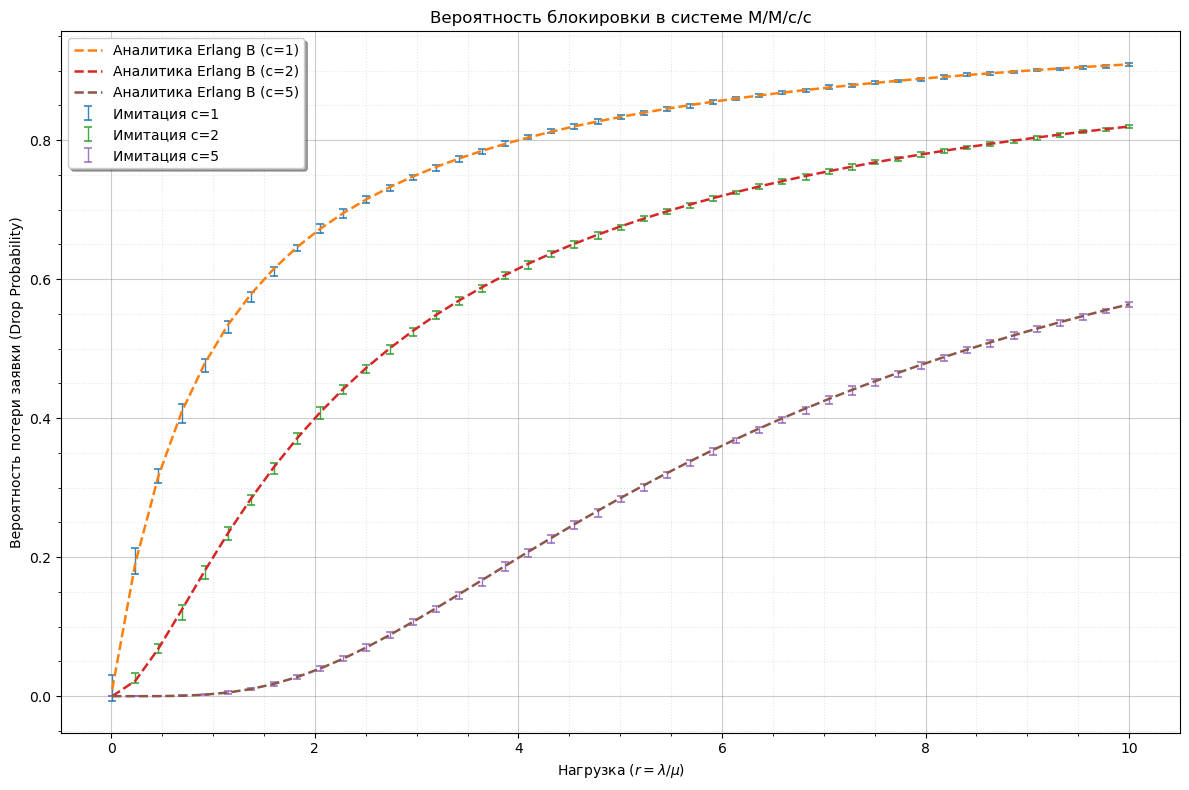

In [14]:
# Визуализация
plot_tools.plot_signals(
    y=y_data_to_plot,
    x=[lambdas_mmcc] * len(y_data_to_plot),
    labels=labels_to_plot,
    linestyles=styles_to_plot,
    errors=errors_to_plot,
    show_err=True,
    title='Вероятность блокировки в системе M/M/c/c',
    xlabel=r'Нагрузка ($r = \lambda/\mu$)',
    ylabel='Вероятность потери заявки (Drop Probability)',
    figsize=(12, 8),
    save_name="mmcc_drop.pdf"
)

In [15]:
mu = 1.0
r_min_mmcc = 0.5
r_max_mmcc = 10.0
c_values = [1, 2, 5]

sim_time=100000

lambdas_mmcc = np.linspace(r_min_mmcc * mu, r_max_mmcc * mu, 10)


y_sojourn_data = []
labels_sojourn = []
errors_sojourn = []
styles_sojourn = []


for c in tqdm(c_values):
    sim_st_means = []
    sim_st_cis = []
    
    for lambd in lambdas_mmcc:
        # mode=2: M/M/c/c
        st_mean, st_ci, _, _ = run_experiment(lambd, mu, sim_time, mode=2, c=c, target_beta=0.1, seed_counter_max=10)
        sim_st_means.append(st_mean)
        sim_st_cis.append(st_ci)
    
    # Симуляция
    y_sojourn_data.append(np.array(sim_st_means))
    errors_sojourn.append((np.array(sim_st_cis), None))
    labels_sojourn.append(f'Имитация c={c}')
    styles_sojourn.append('')


  0%|          | 0/3 [00:00<?, ?it/s]

In [16]:
# Аналитика W = 1/mu
analyt_x = np.linspace(r_min_mmcc, r_max_mmcc, 100)
analyt_y = np.full_like(analyt_x, 1.0/mu)

y_sojourn_data.append(analyt_y)
errors_sojourn.append((None, None))
labels_sojourn.append(r'Аналитика $W = 1/\mu$')
styles_sojourn.append('--')

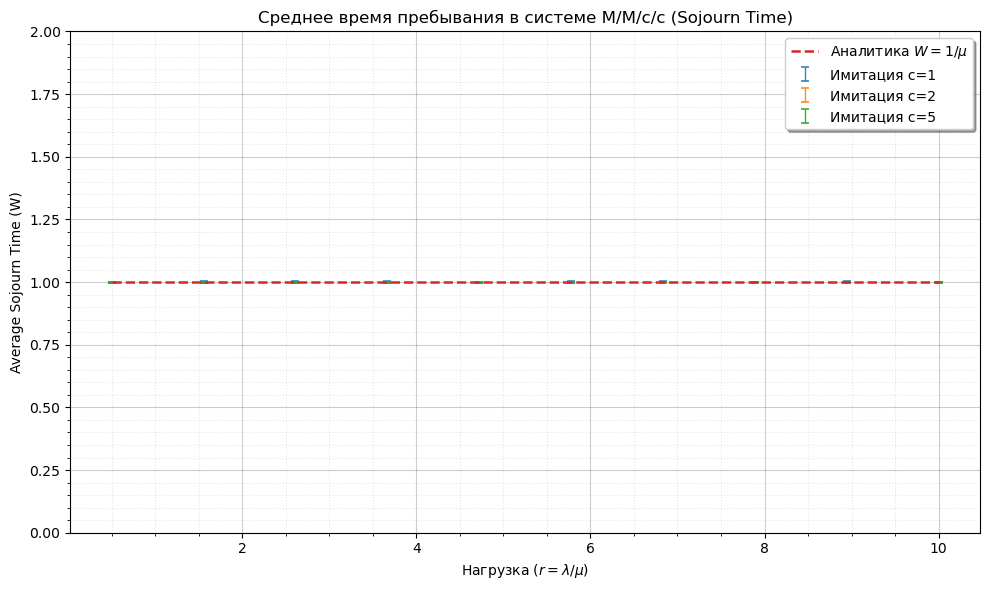

In [17]:
plot_tools.plot_signals(
    y=y_sojourn_data,
    x=[lambdas_mmcc] * len(c_values) + [analyt_x],
    labels=labels_sojourn,
    linestyles=styles_sojourn,
    errors=errors_sojourn,
    show_err=True,
    title='Среднее время пребывания в системе M/M/c/c (Sojourn Time)',
    xlabel=r'Нагрузка ($r = \lambda/\mu$)',
    ylabel='Average Sojourn Time (W)',
    limits = (None, (0, 2)),
    save_name="mmcc_time.pdf"
)

### Краткое описание результатов и заметки
1. **M/M/1:** Имитационное моделирование с высокой точностью ложится на аналитическую кривую $1/(\mu - \lambda)$.
2. **M/U/1:** Для равномерного распределения дисперсия меньше, чем для экспоненциального, ввиду чего очередь (и общее время) растут медленнее. На графиках мы это видим
3. **M/M/c/c:** Системы с отказами не имеют очереди, поэтому время в системе равно времени обслуживания (в среднем $1/\mu$) и не зависит от числа серверов, как мы видим на графике. Вероятность отбрасывания полностью подчиняется формуле Эрланга (Erlang B). При увеличении числа серверов кривая вероятности отбрасывания сдвигается вправо, позволяя удерживать бОльшие нагрузки без потери пакетов.